In [10]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

from scipy.stats import chisquare

from sklearn.mixture import GaussianMixture


In [2]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    'ESP Vibration Module'
    # 'ESP Vibration X',
    # 'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

In [7]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
#totalData.drop(columns=["Unnamed: 0"],inplace=True)

pumpList = totalData["Well Run"].unique()

totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)


C:\Users\Protocolo\AppData\Local\Temp\ipykernel_17712\19200892.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [8]:
seeds = np.random.randint(low=19971215,high=20210505,size=30)

seeds.shape

(30,)

In [ ]:
n = 3

mainSeed = 971215
np.random.seed(mainSeed)

seeds = np.random.randint(low=19971215,high=20210505,size=30)

medianList = np.array([]).astype(int)

for seed in seeds:
    print("Seed " + str(seed))
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

    radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]


    modelGMMradius = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)
    
    modelRadius = hmm.GaussianHMM(
        n_components=n,
        random_state=mainSeed,
        covariance_type="full",
        init_params="st",
        #params="st"
        )

    modelRadius.means_ = modelGMMradius.means_
    modelRadius.covars__ = modelGMMradius.covariances_

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)
    print(str(seed) + " trained")


    li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)

    totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))


    medianList_G = np.array([])

    for pump in X_test["Well Run"].unique():#pumpList: #
        pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        medianList_G = np.append(medianList_G,pumpMedianR)


    medianList = np.concatenate((medianList, medianList_G))
    print(str(seed) + " median list appended")


Seed 20137676


AttributeError: module 'lissa' has no attribute 'GaussianMixtureFit'

In [3]:
saveA = np.array(medianList).T
pd.DataFrame(saveA,columns=["R"]).to_csv(path)

NameError: name 'medianList' is not defined

In [20]:
path = "./tables/saveA_direto_run_nova_teste.csv"
image_path = "../imagens_gerais/multiple_seeds_radius_histogram_pt_teste.jpg"

In [21]:
saveA = pd.read_csv(path)

In [22]:
medianList = saveA["R"].to_numpy()

In [23]:
cmap = plt.get_cmap('Oranges', 4)

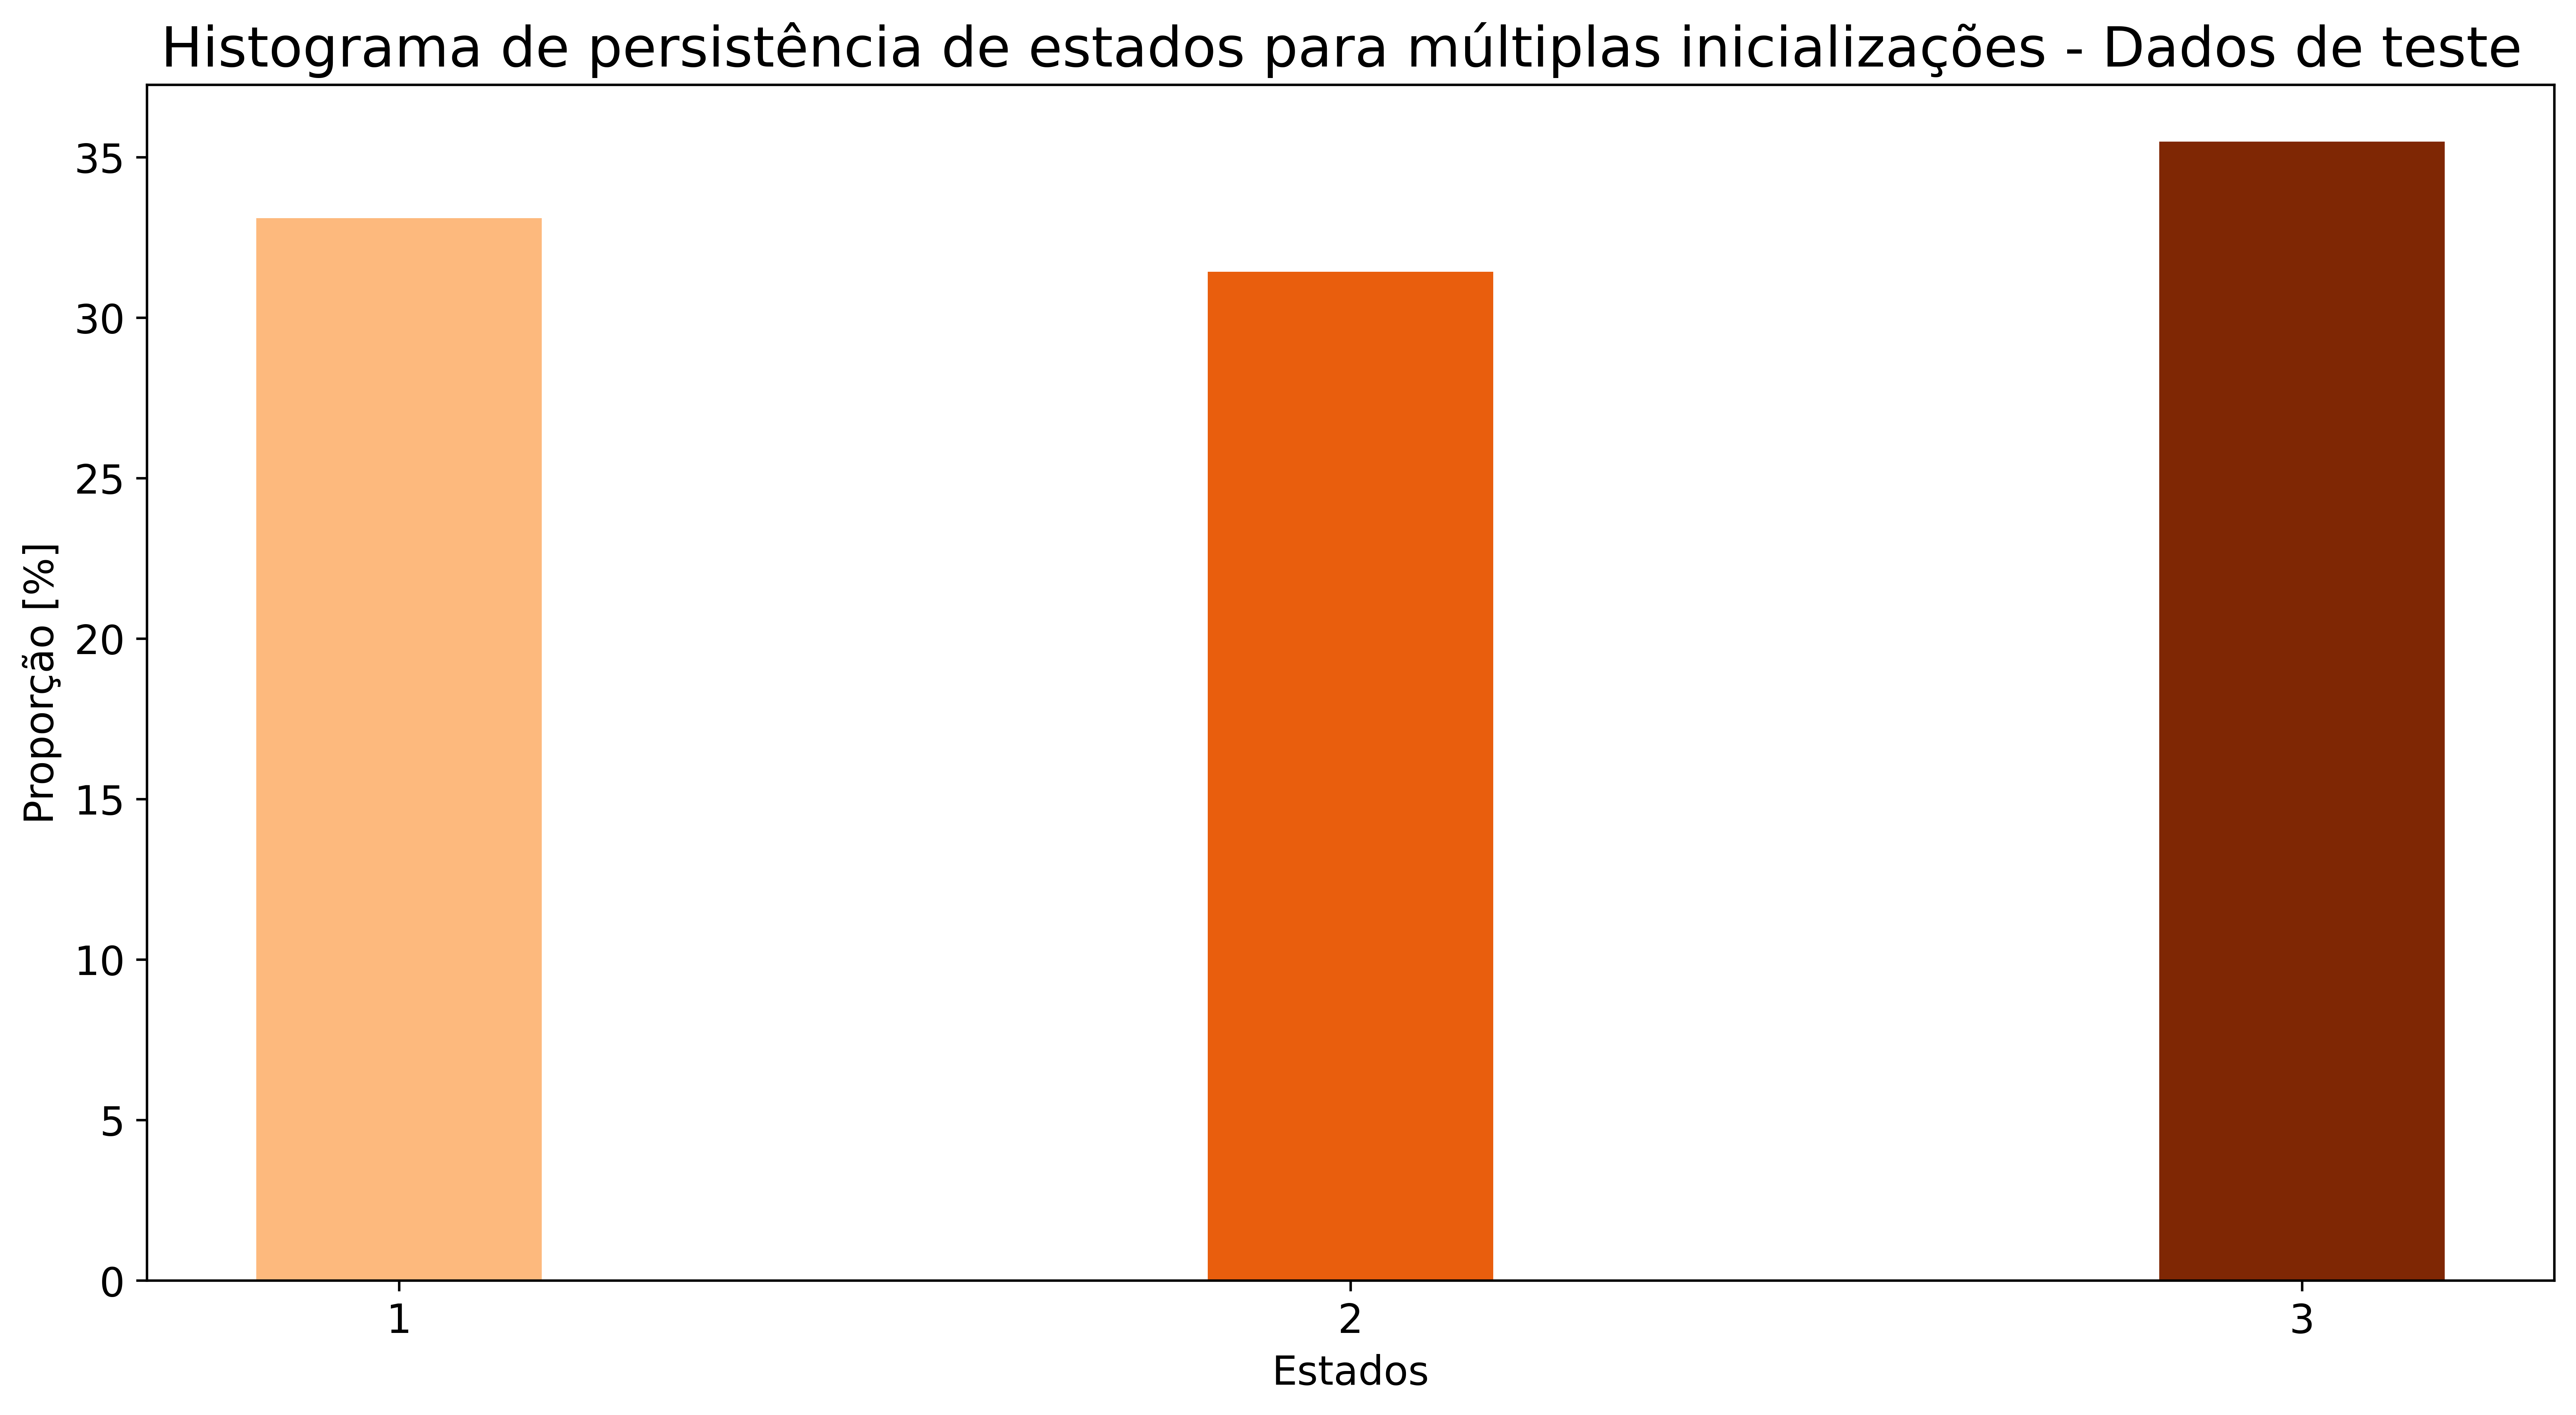

In [24]:

plt.figure(figsize=(14,7))


plt.rcParams.update({
            "font.size"                 :   13,
            "figure.titlesize"          :   20,
            "xtick.labelsize"           :   13,
            "ytick.labelsize"           :   13,
            "axes.labelsize"            :   13,
            "legend.fontsize"           :   13,
            "legend.title_fontsize"     :   13,
            "axes.titlesize"            :   18,
            "figure.dpi"                :   600

        })

states,counts = np.unique(medianList,return_counts=True)

counts = counts/counts.sum()*100

plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
# plt.ylabel("Counts")
# plt.xlabel("States")
# plt.title("Radius Persistence Histogram - Multiple Seeds")
# plt.savefig("../imagens_gerais/multiple_seeds_radius_histogram.jpg")

plt.ylabel("Proporção [%]")
plt.xlabel("Estados")
plt.title("Histograma de persistência de estados para múltiplas inicializações - Dados de teste ")
plt.savefig(image_path)

In [28]:
# plt.figure(figsize=(7,5))
# plt.hist(medianListV)
# plt.title("Histograma da média de Persistência de Estados - Módulo da Vibração")

In [21]:
# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1]+counts[2]]) # Substituir pelos valores reais
expected_counts = np.array([1/2, 1/2]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")

Estatística qui-quadrado: 48.0095, p-valor: 0.0000
Rejeitamos H0: C ocorre significativamente mais do que o esperado.
